# Team 8:-
- Ronak Pipaliya
- Sajan Shergill
- Darpan Gorasiya

Analyze the `diabetes.csv` dataset by training and evaluating both Perceptron and Multilayer Perceptron models.

## Load Diabetes Dataset

### Subtask:
Load the `diabetes.csv` file into a pandas DataFrame.


In [26]:
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Prepare Features and Target

### Subtask:
Identify the features (X) and the target variable (y, 'Outcome') from the `diabetes.csv` dataset.


**Reasoning**:
To prepare the features and target variables for model training, I will separate the `Outcome` column from the DataFrame `df` and assign it to `y`. The remaining columns will be assigned to `X`.



In [27]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (768, 8)
Target (y) shape: (768,)


## Scale Features

### Subtask:
Apply `StandardScaler` to the features (X) of the `diabetes.csv` dataset to normalize the data, which is beneficial for Perceptron models.


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Features (X_scaled) shape:", X_scaled.shape)
print("First 5 rows of scaled features:\n", X_scaled[:5])

Scaled Features (X_scaled) shape: (768, 8)
First 5 rows of scaled features:
 [[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]


## Split Data into Training and Test Sets

### Subtask:
Split the scaled features (X) and target (y) from the `diabetes.csv` dataset into training and testing sets (e.g., 80% train, 20% test) for model development and evaluation.


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


## Train Perceptron Model

### Subtask:
Initialize and train a Perceptron model (`sklearn.linear_model.Perceptron`) using the prepared training data from the `diabetes.csv` dataset.


In [30]:
from sklearn.linear_model import Perceptron

perceptron_model = Perceptron(random_state=42)
perceptron_model.fit(X_train, y_train)

print("Perceptron model trained successfully.")

Perceptron model trained successfully.


## Make Predictions

### Subtask:
Use the trained Perceptron model to make predictions on the test set of the `diabetes.csv` dataset.


In [31]:
y_pred_perceptron = perceptron_model.predict(X_test)

print("Predictions for Perceptron model created successfully.")
print("First 5 predictions:", y_pred_perceptron[:5])

Predictions for Perceptron model created successfully.
First 5 predictions: [0 0 0 1 1]


## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy score, generate a confusion matrix (visualized as a heatmap with annotations), and print a classification report for the Perceptron model's predictions on the `diabetes.csv` test set.


Perceptron Model Accuracy: 0.5130


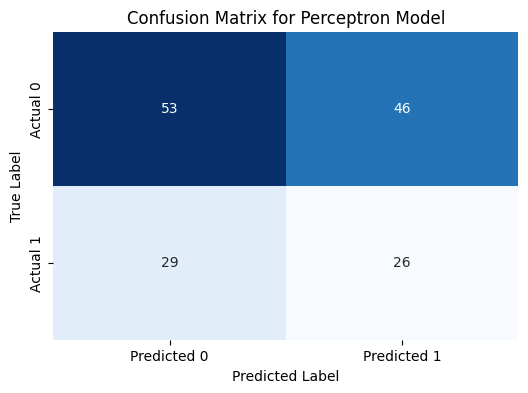


Perceptron Model Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.54      0.59        99
           1       0.36      0.47      0.41        55

    accuracy                           0.51       154
   macro avg       0.50      0.50      0.50       154
weighted avg       0.54      0.51      0.52       154



In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate accuracy score
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)
print(f"Perceptron Model Accuracy: {accuracy_perceptron:.4f}")

# Generate confusion matrix
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Perceptron Model')
plt.show()

# Print classification report
print("\nPerceptron Model Classification Report:")
print(classification_report(y_test, y_pred_perceptron))